# RGB Phasor Unmixing with Phasor Component

This tutorial reproduces **Part 4** of the RGB-Phasor paper analysis:

- Loads three fluorescence components (DAPI, Tubulin488, Laminin555)
- Computes their phasor distributions and centers of mass
- Applies phasor-based spectral unmixing to an experimental RGB image
- Uses `phasorpy.components.phasor_component_fit` exactly as in the paper code
- Visualizes fraction maps, photon maps, histograms, and the unmixed RGB image

This notebook is intended to be run **locally** with your private data.  
You do **not** need to upload the data to the website; only the executed notebook (with outputs) is needed for the docs.

In [1]:
# Fluorescence microscopy phasor analysis
# This script processes fluorescence microscopy images,
# performs unmixing, and visualizes the results.

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from phasorpy.plot import PhasorPlot
from phasorpy.color import CATEGORICAL
from phasorpy.phasor import phasor_from_signal, phasor_threshold
from phasorpy.components import phasor_component_fit
from phasorpy.cursors import mask_from_circular_cursor

import sys, os
sys.path.append(os.path.abspath("../../src"))

from tools4 import (
    build_thresholded_rgb,
    apply_plot_style, 
    rgb2bgr,
    phasor_center_of_mass,
    threshold_by_range,
    apply_unmixing_to_rgb,
    increase_brightness,
    photon_fraction_maps,
    plot_photon_unmixing,
    save_figure,
    draw_dashed_line_on_figures,
    create_combined_profile_plot
    )

# NOTE: adjust these paths if needed for your machine
path2 = "/Users/schutyb/Documents/Projects/rgb-phasors/paper/spectral_unmixing/data/"
path = "/Users/schutyb/Documents/Projects/rgb-phasors/paper/spectral_unmixing/data/"

In [2]:
# --- ..................................................... ---
# --- Part 1 Apply the phasor analysis with pure components ---
# --- ..................................................... ---

# Load the component images
blue = plt.imread(path + "component_dapi.tif")
green = plt.imread(path + "component_tubulin_488.tif")
red = plt.imread(path + "component_laminin_555.tif")

# Channel thresholding
# Thresholds are set to remove noise and retain significant features
changes = True
if changes:
    blue = build_thresholded_rgb(
        blue, thresholds=[0, 255, 0, 255, 0, 255], plotty=False)
    green = build_thresholded_rgb(
        green, thresholds=[0, 255, 0, 255, 0, 255], plotty=False)
    red = build_thresholded_rgb(
        red, thresholds=[60, 255, 0, 255, 0, 255], plotty=False)

# Calculate phasor for each component
avgb, realb, imagb = phasor_from_signal(
    rgb2bgr(blue)[0:, 850:1250, 750:1250], axis=0)
avgg, realg, imagg = phasor_from_signal(
    rgb2bgr(green)[0:, 200:1400, 600:1600], axis=0)
avgr, realr, imagr = phasor_from_signal(
    rgb2bgr(red)[0:, 500:1200, 1100:1600], axis=0)

# Threshold the phasor components
avgb, realb, imagb = phasor_threshold(avgb, realb, imagb, mean_min=20)
avgg, realg, imagg = phasor_threshold(avgg, realg, imagg, mean_min=5)
avgr, realr, imagr = phasor_threshold(avgr, realr, imagr, mean_min=25)

# Calculate the center of mass for each component
realb_cm, imagb_cm  = phasor_center_of_mass(realb, imagb, avgb)
realg_cm, imagg_cm  = phasor_center_of_mass(realg, imagg, avgg)
realr_cm, imagr_cm  = phasor_center_of_mass(realr, imagr, avgr)

if not print:
    # Print the center of mass for each component
    print(f"Blue center of mass: {realb_cm}, {imagb_cm}")
    print(f"Green center of mass: {realg_cm}, {imagg_cm}")
    print(f"Red center of mass: {realr_cm}, {imagr_cm}")

# Plot the phasor components
# plot histograms for each channel and print the mean values
plotty = False
if plotty:
    # Create figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))

    # --- Top row: Images ---
    axes[0, 0].imshow(blue, interpolation='nearest', cmap='Blues')
    axes[0, 0].set_title("Blue Channel")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(green, interpolation='nearest', cmap='Greens')
    axes[0, 1].set_title("Green Channel")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(red, interpolation='nearest', cmap='Reds')
    axes[0, 2].set_title("Red Channel")
    axes[0, 2].axis("off")

    # --- Bottom row: Histograms ---
    hist_b, bins_b = np.histogram(avgb, bins=256, range=(0, 255))
    axes[1, 0].plot(bins_b[:-1], hist_b, color='blue')
    axes[1, 0].set_yscale('log')
    axes[1, 0].set_title("Histogram (Blue)")
    axes[1, 0].set_xlim(0, 255)

    hist_g, bins_g = np.histogram(avgg, bins=256, range=(0, 255))
    axes[1, 1].plot(bins_g[:-1], hist_g, color='green')
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title("Histogram (Green)")
    axes[1, 1].set_xlim(0, 255)

    hist_r, bins_r = np.histogram(avgr, bins=256, range=(0, 255))
    axes[1, 2].plot(bins_r[:-1], hist_r, color='red')
    axes[1, 2].set_yscale('log')
    axes[1, 2].set_title("Histogram (Red)")
    axes[1, 2].set_xlim(0, 255)

    plot = PhasorPlot(allquadrants=True, title='Components Phasor Plot')
    plot.hist2d(realb.flatten(), imagb.flatten(), cmap="RdYlGn_r")
    plt.plot(realb_cm, imagb_cm, color='blue', markersize=9, marker='o', 
                linestyle='None', label='Blue component')
    
    plot.hist2d(realg.flatten(), imagg.flatten(), cmap="RdYlGn_r")
    plt.plot(realg_cm, imagg_cm, color='green', markersize=9, marker='p', 
                linestyle='None', label='Green component')
    
    plot.hist2d(realr.flatten(), imagr.flatten(), cmap="RdYlGn_r")
    plt.plot(realr_cm, imagr_cm, color='red', markersize=9, marker='*', 
                linestyle='None', label='Red component')
    plt.legend()
    plt.show()

/var/folders/mb/zl02x_nn29389qvmzgtjcgn00000gn/T/ipykernel_25000/3643165626.py:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs[0].show()
/var/folders/mb/zl02x_nn29389qvmzgtjcgn00000gn/T/ipykernel_25000/3643165626.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs[1].show()
/var/folders/mb/zl02x_nn29389qvmzgtjcgn00000gn/T/ipykernel_25000/3643165626.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figs[1].show()


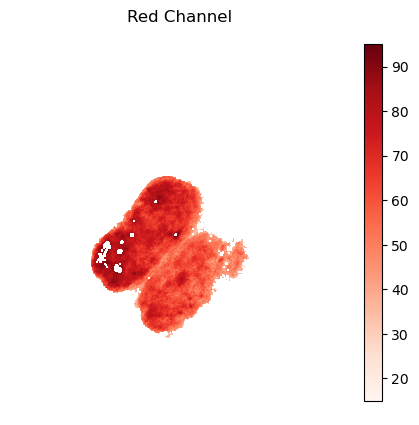

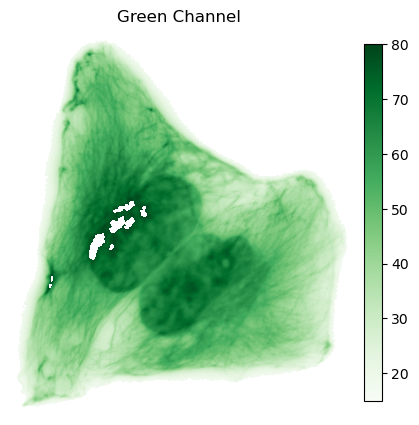

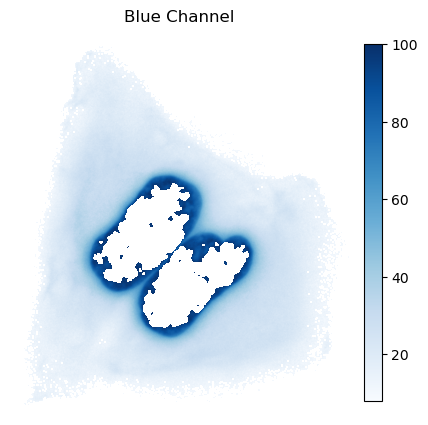

In [3]:
# --- .............................................................. ---
# --- Part 2 Apply the phasor unmixing to the RGB experimental image ---
# --- .............................................................. ---

image = plt.imread(path + "sample1.tif")[150:1800, 600:2050] # Select region of interest in the image
threshold = [5, 120, 5, 100, 5, 130]
rang = np.array([[0.15, 0.95], [0, 0.8], [0.03, 0.4]])
mean_threshold = 8 

##################################################
#           Plot each channel separated
##################################################
from matplotlib.colors import Normalize

# Separate channels
R, G, B = image[:,:,0], image[:,:,1], image[:,:,2]

B = threshold_by_range(B, 8, 100)
G = threshold_by_range(G, 15, 80)
R = threshold_by_range(R, 15, 95)

channel_data = [
    (R, "Red Channel", "Reds"),
    (G, "Green Channel", "Greens"),
    (B, "Blue Channel", "Blues")
]

figs = []

for channel, title, cmap in channel_data:
    fig_ch, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(channel, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    figs.append(fig_ch)

figs[0].show() 
figs[1].show() 
figs[1].show()

In [4]:
# Build the thresholded RGB image
rgb_composed = build_thresholded_rgb(image, 
                    thresholds=threshold, plotty=False)

img = rgb2bgr(rgb_composed) # Convert RGB to BGR
# img = rgb2bgr(image) # Convert RGB to BGR
avg, real, imag = phasor_from_signal(img, axis=0)
avg, real, imag = phasor_threshold(avg, real, imag, 
                                   mean_min=mean_threshold)

(-0.5, 1449.5, 1649.5, -0.5)

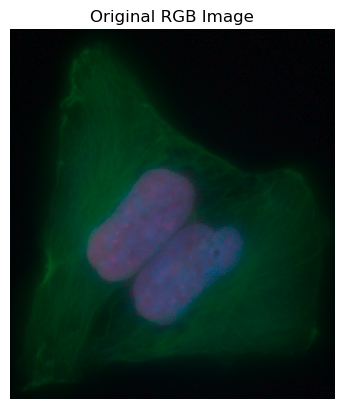

In [5]:
# Plot the original RGB image
fig1 = plt.figure()
plt.imshow(image, interpolation="nearest")
plt.title("Original RGB Image")
plt.axis("off") 

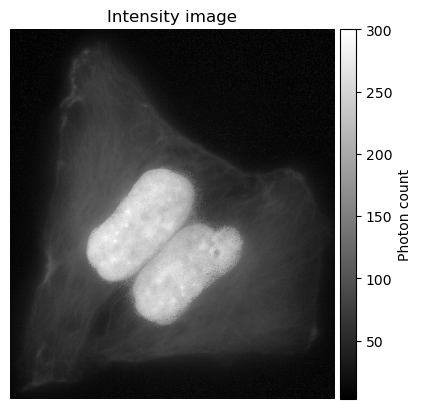

In [6]:
# Plot the intensity image
# This shows the sum of the RGB channels as a grayscale image
fig2, ax2 = plt.subplots()
im = ax2.imshow(np.sum(image, axis=2), cmap="gray", interpolation="nearest")
ax2.set_title("Intensity image")
ax2.axis("off")
# Add a colorbar to the intensity image
divider = make_axes_locatable(ax2)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("Photon count")

In [7]:
##################################################
#          Spectral Unmixing Analysis 
##################################################

# Components center of mass
gs = np.array([realb_cm, realg_cm, realr_cm])
ss = np.array([imagb_cm, imagg_cm, imagr_cm])

# Unmix the phasor components (key line!)
frac = phasor_component_fit(avg, real, imag, gs, ss)

fracb = threshold_by_range(frac[0], rang[0][0], rang[0][1])
fracg = threshold_by_range(frac[1], rang[1][0], rang[1][1])
fracr = threshold_by_range(frac[2], rang[2][0], rang[2][1])

rgb_unmixed = apply_unmixing_to_rgb(image, fracr, fracg, fracb)
rgb_adjusted = increase_brightness(rgb_unmixed, factor=3)

R_photons, G_photons, B_photons = photon_fraction_maps(image, fracr, fracg, fracb)

/Users/schutyb/Documents/Projects/rgb-phasors/rgb-phasors/src/tools4.py:256: RuntimeWarning: invalid value encountered in cast
  return (img_bright * 255).astype(np.uint8)


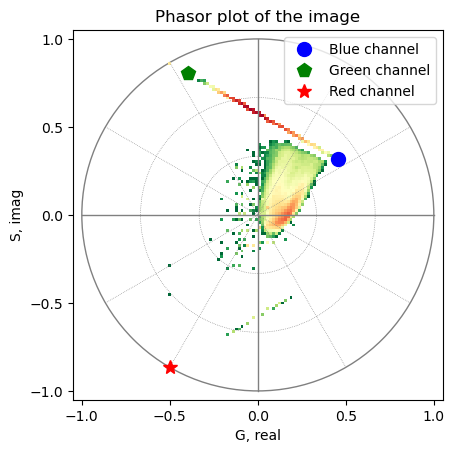

In [8]:
# Figure Phasor Plot
plot = PhasorPlot(allquadrants=True, title='Phasor plot of the image')
plot.hist2d(real.flatten(), imag.flatten(), cmap="RdYlGn_r")
plt.plot(realb_cm, imagb_cm, color='blue', markersize=10, marker='o', 
        linestyle='None', label='Blue channel')
plt.plot(realg_cm, imagg_cm, color='green', markersize=10, marker='p', 
        linestyle='None', label='Green channel')
plt.plot(realr_cm, imagr_cm, color='red', markersize=10, marker='*', 
        linestyle='None', label='Red channel')
plt.legend()
fig3 = plot.fig

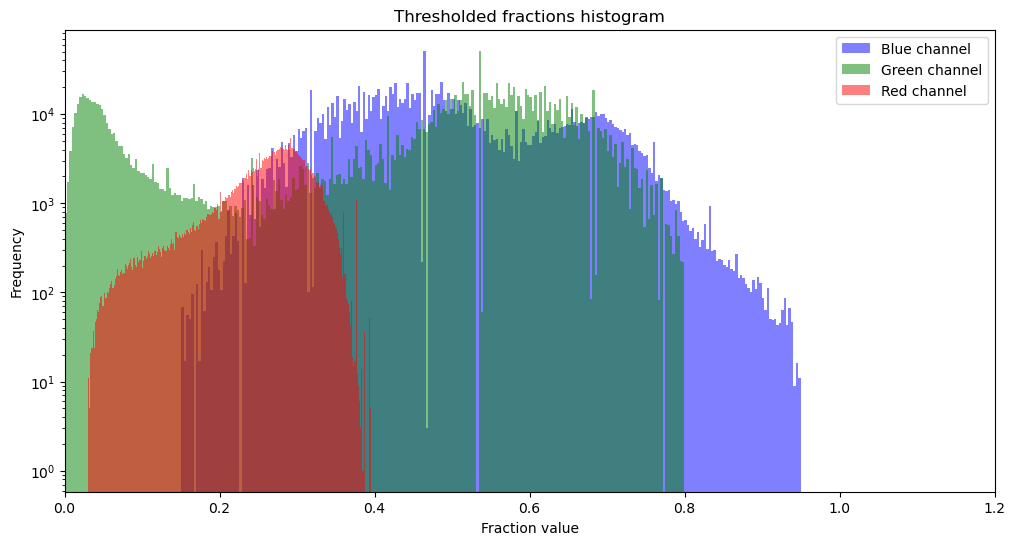

In [9]:
# Plot Thresholded Fractions Histogram
fig5, ax5 = plt.subplots(figsize=(12, 6))
ax5.hist(fracb.flatten()[fracb.flatten() != 0],
        bins=256, color='blue', alpha=0.5, label='Blue channel', log=True)
ax5.hist(fracg.flatten()[fracg.flatten() != 0],
        bins=256, color='green', alpha=0.5, label='Green channel', log=True)
ax5.hist(fracr.flatten()[fracr.flatten() != 0],
        bins=256, color='red', alpha=0.5, label='Red channel', log=True)
ax5.set_title("Thresholded fractions histogram")
ax5.set_xlabel("Fraction value")
ax5.set_ylabel("Frequency")
ax5.set_xlim(0, 1.2)
ax5.legend()

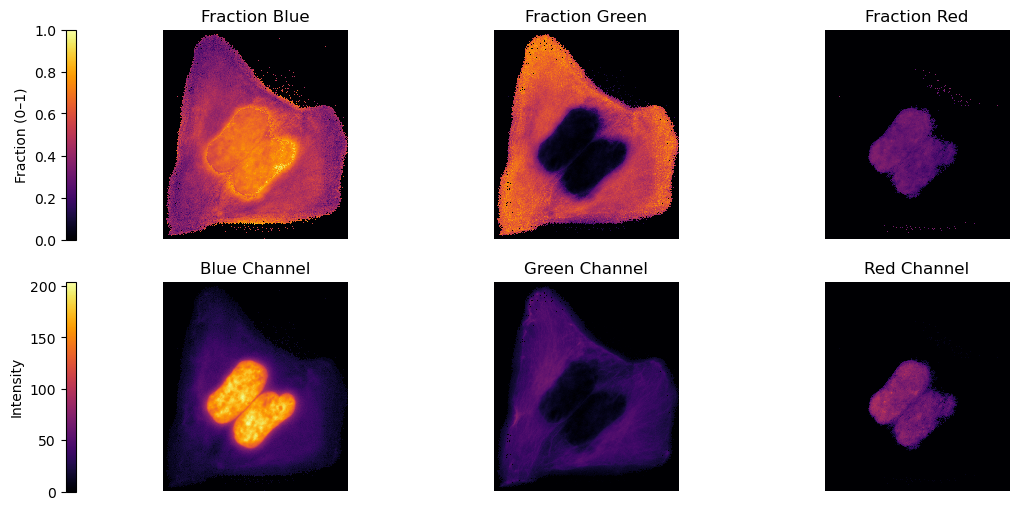

In [10]:
# Plot the photon unmixing results
fig6 = plot_photon_unmixing(fracr, fracg, fracb, R_photons, G_photons, B_photons)

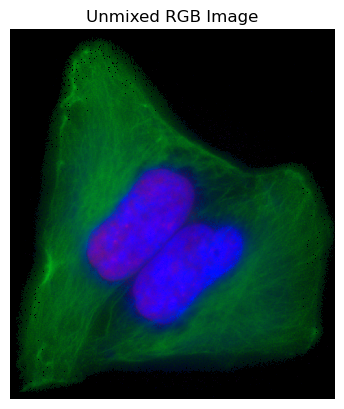

In [11]:
# Plot the unmixed RGB image
fig7, ax7 = plt.subplots()

plt.imshow(rgb_adjusted, interpolation="nearest")
plt.title("Unmixed RGB Image")
plt.axis("off")
plt.show()